# Bank Fragility â€” Exploratory Data Analysis
Loads and explores the parquet files in `_data/`.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path('../.env'))

DATA_DIR   = Path('../_data')
OUTPUT_DIR = Path('../_output')

REPORT_DATE_SLASH = os.getenv("REPORT_DATE_SLASH", "12/31/2025")  # MM/DD/YYYY
REPORT_DATE       = REPORT_DATE_SLASH.replace("/", "")

sys.path.insert(0, str(Path('../scripts').resolve()))
from pull_gsib_banks import pull_gsib_list

gsib     = pd.read_parquet(DATA_DIR / 'gsib_list.parquet')
mbs      = pd.read_parquet(DATA_DIR / 'mbs_etfs.parquet')
treasury = pd.read_parquet(DATA_DIR / 'treasury_yields.parquet')
panel    = pd.read_parquet(DATA_DIR / f'bank_panel_{REPORT_DATE}.parquet')
shocks   = pd.read_parquet(DATA_DIR / 'market_shocks.parquet')

SMALL_CUTOFF = 1.384e6
gsib_ids = set(gsib['rssd_id_call'])

panel['bank_category'] = 'Small'
panel.loc[panel['Total Asset'] >= SMALL_CUTOFF, 'bank_category'] = 'Large'
panel.loc[panel['rssd_id_call'].isin(gsib_ids), 'bank_category'] = 'GSIB'

start_date = pd.to_datetime('2020-01-01')
end_date   = pd.to_datetime(f"{REPORT_DATE[4:]}-{REPORT_DATE[:2]}-{REPORT_DATE[2:4]}")

print(f'Report date : {REPORT_DATE_SLASH}')
print(f'Shock window: 2020-01-01  ->  {end_date.date()}')
print('All data loaded.')

Report date : 12/31/2025
Shock window: 2020-01-01  ->  2025-12-31
All data loaded.


## 1. GSIB List

In [2]:
print('Shape:', gsib.shape)
print('Dtypes:\n', gsib.dtypes)
gsib.head(10)

Shape: (37, 2)
Dtypes:
 rssd_id_call    int32
is_gsib         int64
dtype: object


,rssd_id_call,is_gsib
0,934329,1
1,488318,1
2,212465,1
3,449038,1
4,476810,1
5,3382547,1
6,852218,1
7,651448,1
8,480228,1
9,1443266,1


In [3]:
print('Missing values:\n', gsib.isna().sum())
print('\nUnique banks:', gsib['rssd_id_call'].nunique())

Missing values:
 rssd_id_call    0
is_gsib         0
dtype: int64

Unique banks: 37


## 2. MBS ETFs

In [4]:
print('Shape:', mbs.shape)
print('Dtypes:\n', mbs.dtypes)
mbs.head()

Shape: (3553, 10)
Dtypes:
 date          datetime64[ns]
mbs_px               float64
tsy_bmark            float64
tsy_lt1y             float64
tsy_1_3y             float64
tsy_3_5y             float64
tsy_5_10y            float64
tsy_10_15y           float64
tsy_15plus           float64
mbs_ret              float64
dtype: object


,date,mbs_px,tsy_bmark,tsy_lt1y,tsy_1_3y,tsy_3_5y,tsy_5_10y,tsy_10_15y,tsy_15plus,mbs_ret
0,2012-02-24,108.190002,24.82,110.199997,84.379997,121.830002,105.139999,131.440002,117.500000,NaN
1,2012-02-27,108.190002,24.82,110.180000,84.400002,122.080002,105.489998,132.190002,118.540001,0.000000
2,2012-02-28,108.260002,24.82,110.199997,84.419998,122.110001,105.540001,132.110001,118.150002,0.000647
3,2012-02-29,108.190002,24.82,110.199997,84.419998,121.919998,105.120003,131.449997,117.430000,-0.000647
4,2012-03-01,107.879997,24.82,110.180000,84.370003,121.690002,104.610001,130.350006,116.059998,-0.002865


In [5]:
print('Date range:', mbs['date'].min().date(), 'to', mbs['date'].max().date())
print('\nMissing values:\n', mbs.isna().sum())
print('\nSummary stats:')
mbs.describe()

Date range: 2012-02-24 to 2026-04-13

Missing values:
 date          0
mbs_px        0
tsy_bmark     0
tsy_lt1y      0
tsy_1_3y      0
tsy_3_5y      0
tsy_5_10y     0
tsy_10_15y    0
tsy_15plus    0
mbs_ret       1
dtype: int64

Summary stats:


,date,mbs_px,tsy_bmark,tsy_lt1y,tsy_1_3y,tsy_3_5y,tsy_5_10y,tsy_10_15y,tsy_15plus,mbs_ret
count,3553,3553.000000,3553.000000,3553.000000,3553.000000,3553.000000,3553.000000,3553.000000,3553.000000,3552.000000
mean,2019-03-17 15:46:21.311567872,103.624087,24.795343,110.326935,83.984379,122.459254,104.947245,129.653400,119.353310,-0.000032
min,2012-02-24 00:00:00,85.820000,21.600000,109.739998,80.510002,111.610001,88.949997,93.110001,82.769997,-0.031457
25%,2015-09-04 00:00:00,96.209999,23.500000,110.230003,82.900002,119.330002,99.470001,115.000000,104.800003,-0.001110
50%,2019-03-19 00:00:00,106.739998,24.969999,110.290001,84.430000,122.360001,105.169998,133.039993,120.239998,0.000092
75%,2022-09-26 00:00:00,108.570000,25.600000,110.419998,84.790001,124.879997,109.239998,139.820007,130.679993,0.001149
max,2026-04-13 00:00:00,111.239998,28.299999,111.070000,86.800003,134.100006,123.059998,172.330002,171.570007,0.031339
std,NaN,6.664312,1.445375,0.173452,1.468642,4.920696,7.535816,17.602998,20.057552,0.002987


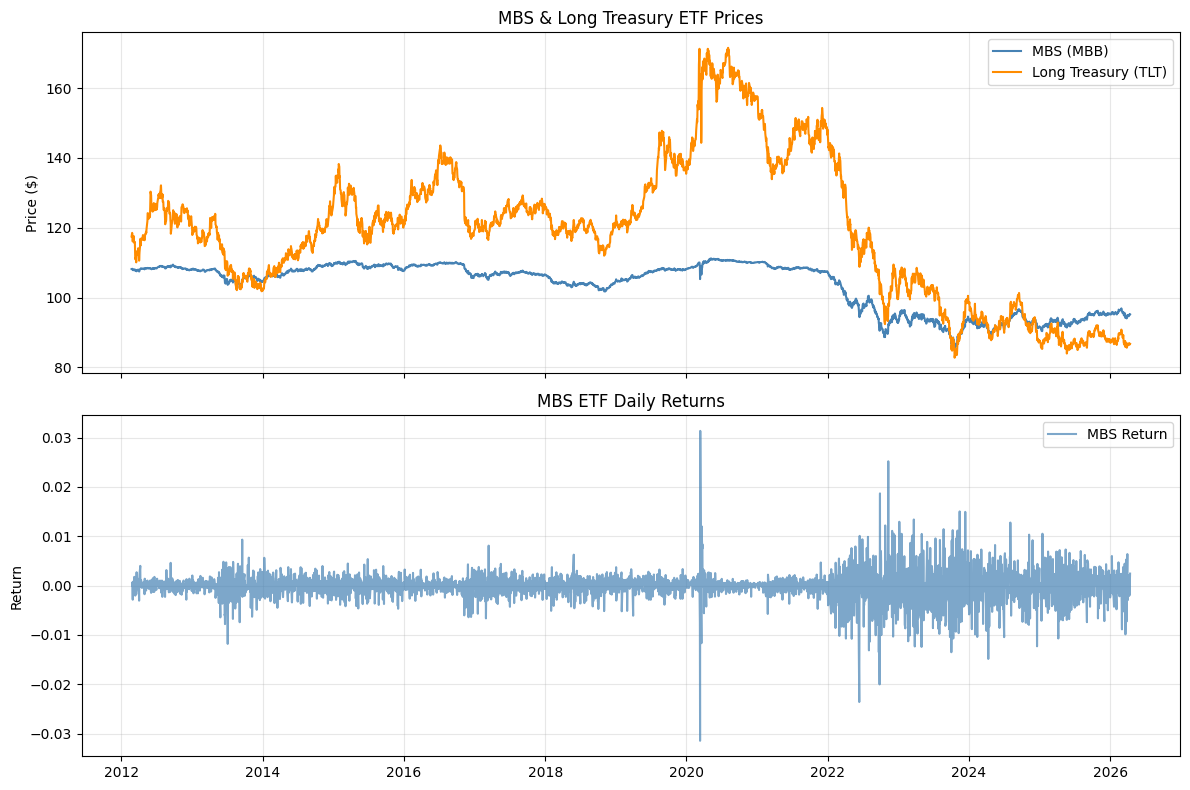

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(mbs['date'], mbs['mbs_px'], label='MBS (MBB)', color='steelblue')
axes[0].plot(mbs['date'], mbs['tsy_15plus'], label='Long Treasury (TLT)', color='darkorange')
axes[0].set_title('MBS & Long Treasury ETF Prices')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mbs['date'], mbs['mbs_ret'], label='MBS Return', color='steelblue', alpha=0.7)
axes[1].set_title('MBS ETF Daily Returns')
axes[1].set_ylabel('Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Treasury Yields

In [7]:
print('Shape:', treasury.shape)
print('Dtypes:\n', treasury.dtypes)
treasury.head()

Shape: (16053, 7)
Dtypes:
 date     datetime64[ns]
dgs1            float64
dgs3            float64
dgs5            float64
dgs10           float64
dgs20           float64
dgs30           float64
dtype: object


,date,dgs1,dgs3,dgs5,dgs10,dgs20,dgs30
0,1962-01-02,3.22,3.70,3.88,4.06,4.07,NaN
1,1962-01-03,3.24,3.70,3.87,4.03,4.07,NaN
2,1962-01-04,3.24,3.69,3.86,3.99,4.06,NaN
3,1962-01-05,3.26,3.71,3.89,4.02,4.07,NaN
4,1962-01-08,3.31,3.71,3.91,4.03,4.08,NaN


In [8]:
print('Date range:', treasury['date'].min().date(), 'to', treasury['date'].max().date())
print('\nMissing values:\n', treasury.isna().sum())
print('\nSummary stats:')
treasury.describe()

Date range: 1962-01-02 to 2026-04-10

Missing values:
 date        0
dgs1        0
dgs3        0
dgs5        0
dgs10       0
dgs20    1689
dgs30    3770
dtype: int64

Summary stats:


,date,dgs1,dgs3,dgs5,dgs10,dgs20,dgs30
count,16053,16053.000000,16053.000000,16053.000000,16053.000000,14364.000000,12283.000000
mean,1994-03-01 04:13:19.252476160,4.878435,5.245192,5.488732,5.813398,5.852245,6.164362
min,1962-01-02 00:00:00,0.040000,0.100000,0.190000,0.520000,0.870000,0.990000
25%,1978-02-07 00:00:00,2.310000,2.850000,3.290000,3.890000,4.060000,3.900000
50%,1994-03-10 00:00:00,4.910000,5.010000,5.230000,5.430000,5.230000,5.460000
75%,2010-03-25 00:00:00,6.660000,7.170000,7.380000,7.540000,7.250000,8.060000
max,2026-04-10 00:00:00,17.310000,16.590000,16.270000,15.840000,15.780000,15.210000
std,NaN,3.355994,3.251182,3.130030,2.936782,2.835994,2.982892


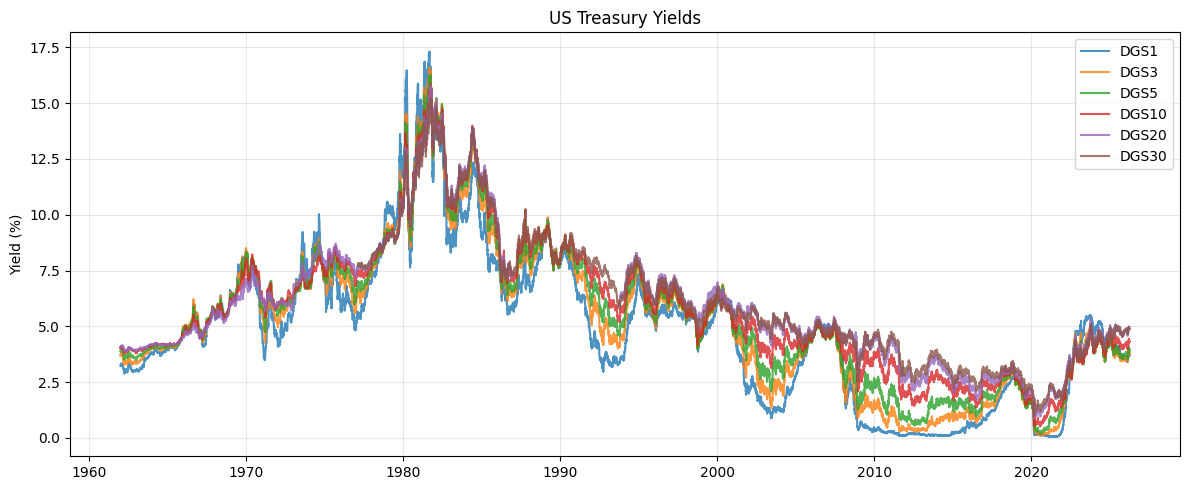

In [9]:
yield_cols = ['dgs1', 'dgs3', 'dgs5', 'dgs10', 'dgs20', 'dgs30']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(12, 5))
for col, color in zip(yield_cols, colors):
    plt.plot(treasury['date'], treasury[col], label=col.upper(), color=color, alpha=0.8)

plt.title('US Treasury Yields')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

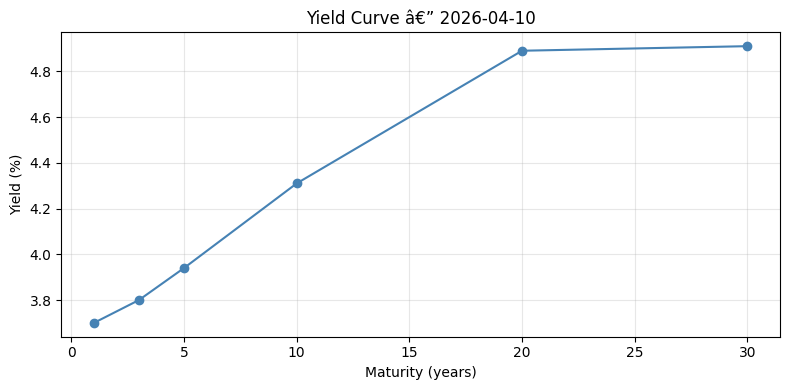

In [10]:
latest = treasury.dropna(subset=yield_cols, how='any').iloc[-1]
maturities = [1, 3, 5, 10, 20, 30]

plt.figure(figsize=(8, 4))
plt.plot(maturities, [latest[c] for c in yield_cols], marker='o', color='steelblue')
plt.title(f"Yield Curve â€” {latest['date'].date()}")
plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. FFIEC Bank Panel

In [11]:
print('Shape:', panel.shape)
print('Columns:', panel.columns.tolist())
panel.head()

Shape: (4394, 67)
Columns: ['rssd_id_call', 'Total Asset', 'cash', 'security_total', 'security_treasury', 'security_rmbs', 'security_cmbs', 'security_abs', 'security_other', 'Total_Loan', 'Real_Estate_Loan', 'Residential_Mortgage', 'Commercial_Mortgage', 'Other_Real_Estate_Mortgage', 'Agri_Loan', 'Comm_Indu_Loan', 'Consumer_Loan', 'Non_Rep_Loan', 'Fed_Fund_Sold', 'Reverse_Repo', 'rmbs_lt1y', 'rmbs_1_3y', 'rmbs_3_5y', 'rmbs_5_10y', 'rmbs_10_15y', 'rmbs_15plus', 'treasury_lt1y', 'other_assets_lt1y', 'res_mtg_lt1y', 'other_loan_lt1y', 'treasury_1_3y', 'other_assets_1_3y', 'res_mtg_1_3y', 'other_loan_1_3y', 'treasury_3_5y', 'other_assets_3_5y', 'res_mtg_3_5y', 'other_loan_3_5y', 'treasury_5_10y', 'other_assets_5_10y', 'res_mtg_5_10y', 'other_loan_5_10y', 'treasury_10_15y', 'other_assets_10_15y', 'res_mtg_10_15y', 'other_loan_10_15y', 'treasury_15plus', 'other_assets_15plus', 'res_mtg_15plus', 'other_loan_15plus', 'Total Liability', 'Domestic Deposit', 'Insured Deposit', 'Uninsured Deposit'

,rssd_id_call,Total Asset,cash,security_total,security_treasury,security_rmbs,security_cmbs,security_abs,security_other,Total_Loan,...,Foreign Deposit,Fed Fund Purchase,Repo,Other Liability,Total Equity,Common Stock,Preferred Stock,Retained Earning,report_date,bank_category
0,37,86116.0,17422.0,47217.0,0.0,0.0,0.0,0.0,0.0,19485.0,...,NaN,0,0.0,127.0,13639.0,1200.0,0.0,12897.0,12312025,Small
1,242,56044.0,3138.0,18513.0,3118.0,0.0,0.0,0.0,0.0,30386.0,...,NaN,0,0.0,84.0,5282.0,120.0,0.0,6106.0,12312025,Small
2,279,428509.0,9370.0,76636.0,0.0,0.0,0.0,0.0,0.0,306644.0,...,NaN,0,0.0,2560.0,48665.0,1.0,0.0,34475.0,12312025,Small
3,354,123554.0,4170.0,2128.0,501.0,0.0,0.0,0.0,0.0,98393.0,...,NaN,0,0.0,922.0,12729.0,100.0,0.0,-1492.0,12312025,Small
4,457,87633.0,5864.0,493.0,493.0,0.0,0.0,0.0,0.0,79786.0,...,NaN,0,0.0,278.0,8097.0,60.0,0.0,3107.0,12312025,Small


### 4.1 Bank Counts by Category

Bank counts by category:
bank_category
Small    3572
Large     788
GSIB       34
Name: count, dtype: int64


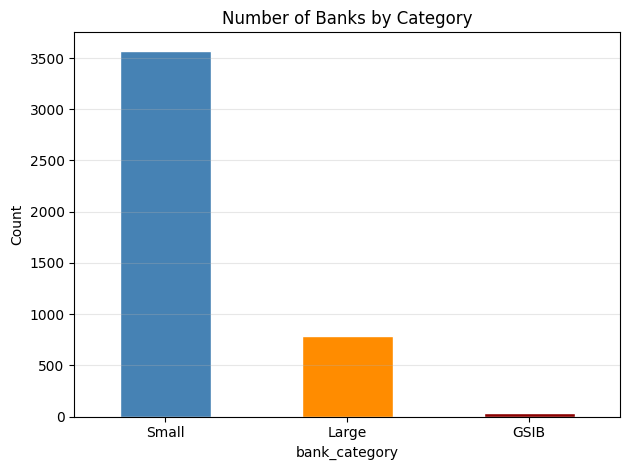

In [12]:
counts = panel['bank_category'].value_counts()
print('Bank counts by category:')
print(counts)

counts.plot(kind='bar', color=['steelblue', 'darkorange', 'darkred'], edgecolor='white')
plt.title('Number of Banks by Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Total Assets Distribution

Total assets across all banks: $25.28T

Assets by category ($T):
bank_category
GSIB     12.50
Large    11.41
Small     1.37
Name: Total Asset, dtype: float64


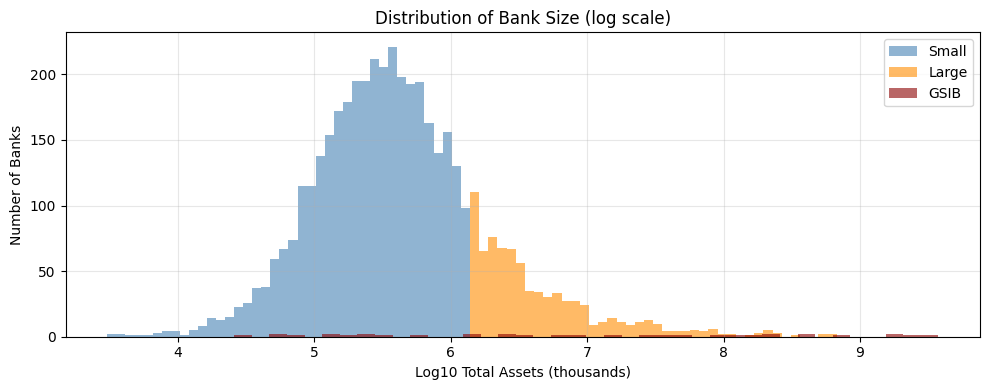

In [13]:
total_assets_T = panel['Total Asset'].sum() / 1e9
print(f'Total assets across all banks: ${total_assets_T:.2f}T')
print(f'\nAssets by category ($T):')
print((panel.groupby('bank_category')['Total Asset'].sum() / 1e9).round(2))

plt.figure(figsize=(10, 4))
for cat, color in zip(['Small', 'Large', 'GSIB'], ['steelblue', 'darkorange', 'darkred']):
    subset = panel[panel['bank_category'] == cat]['Total Asset'].dropna()
    plt.hist(np.log10(subset[subset > 0]), bins=40, alpha=0.6, label=cat, color=color)

plt.xlabel('Log10 Total Assets (thousands)')
plt.ylabel('Number of Banks')
plt.title('Distribution of Bank Size (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Asset Composition

Asset composition (% of total assets):
Cash              10.2
Securities        21.7
Total Loan        53.3
Fed Funds Sold     0.1
Reverse Repo       2.7
dtype: float64


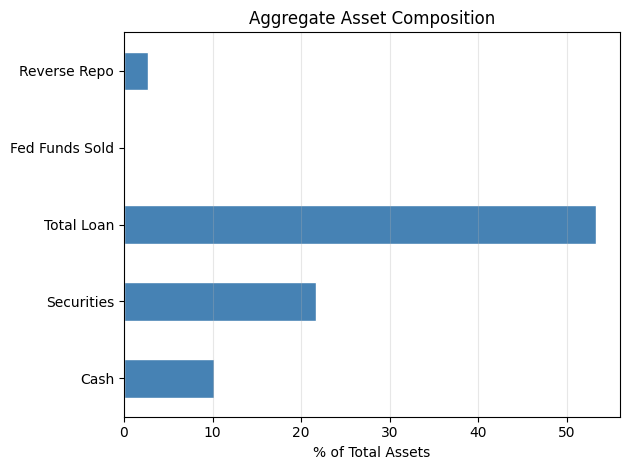

In [14]:
asset_cols = {
    'Cash': 'cash',
    'Securities': 'security_total',
    'Total Loan': 'Total_Loan',
    'Fed Funds Sold': 'Fed_Fund_Sold',
    'Reverse Repo': 'Reverse_Repo',
}

agg = {label: panel[col].sum() for label, col in asset_cols.items() if col in panel.columns}
agg_pct = (pd.Series(agg) / panel['Total Asset'].sum() * 100).round(1)

print('Asset composition (% of total assets):')
print(agg_pct)

agg_pct.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('% of Total Assets')
plt.title('Aggregate Asset Composition')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Securities Breakdown

Securities as % of total assets:
Treasury    6.22
RMBS        7.52
CMBS        1.09
ABS         0.25
Other       1.70
dtype: float64


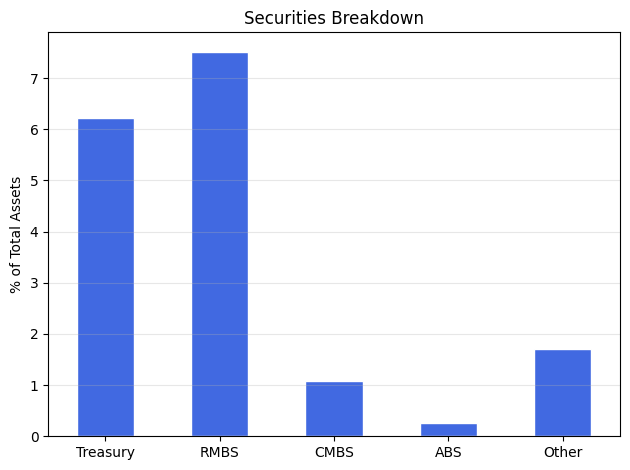

In [15]:
sec_cols = {
    'Treasury': 'security_treasury',
    'RMBS': 'security_rmbs',
    'CMBS': 'security_cmbs',
    'ABS': 'security_abs',
    'Other': 'security_other',
}

sec_pct = (pd.Series({l: panel[c].sum() for l, c in sec_cols.items() if c in panel.columns}) / panel['Total Asset'].sum() * 100).round(2)

print('Securities as % of total assets:')
print(sec_pct)

sec_pct.plot(kind='bar', color='royalblue', edgecolor='white')
plt.ylabel('% of Total Assets')
plt.title('Securities Breakdown')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Asset Composition by Bank Category

          Cash  Securities  Total Loan  Fed Funds Sold  Reverse Repo
Category                                                            
Small      8.2        19.1        67.5             0.9           0.0
Large      7.6        20.5        64.2             0.0           0.2
GSIB      12.8        23.1        41.8             0.0           5.3


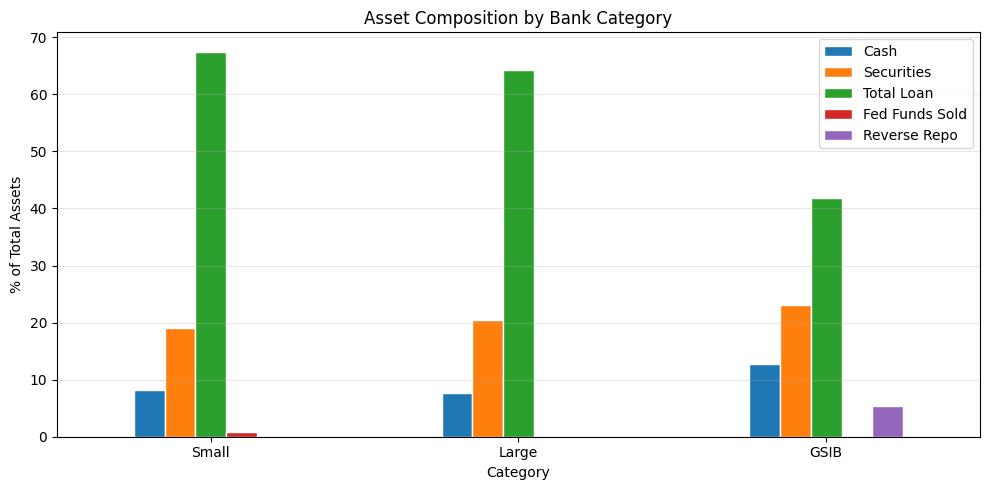

In [16]:
cat_order = ['Small', 'Large', 'GSIB']

rows = []
for cat in cat_order:
    sub = panel[panel['bank_category'] == cat]
    total = sub['Total Asset'].sum()
    row = {'Category': cat}
    for label, col in asset_cols.items():
        if col in panel.columns:
            row[label] = round(sub[col].sum() / total * 100, 1)
    rows.append(row)

cat_df = pd.DataFrame(rows).set_index('Category')
print(cat_df)

cat_df.plot(kind='bar', figsize=(10, 5), edgecolor='white')
plt.ylabel('% of Total Assets')
plt.title('Asset Composition by Bank Category')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Missing Values

In [17]:
missing = panel.isna().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]
print(f'{len(missing_nonzero)} columns have missing values out of {len(panel.columns)}')
print()
print((missing_nonzero * 100).round(1).to_string())

2 columns have missing values out of 67

Foreign Deposit    98.7
Repo                0.6
